In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [19]:
df = pd.read_csv('height-weight.csv')

In [20]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


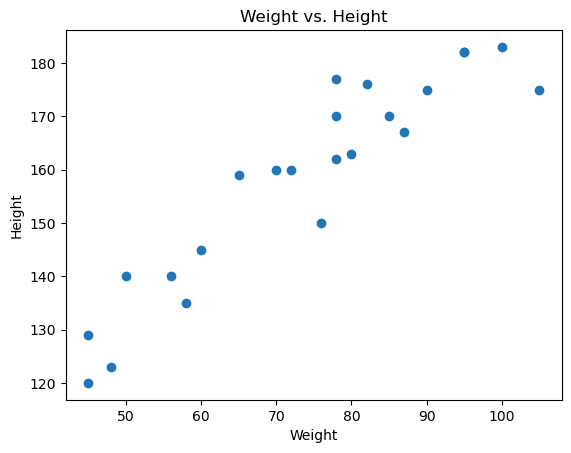

In [21]:
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Weight vs. Height')
plt.show()

In [22]:
#Independednt and Dependent Variable
## Independent feature has to be in 2D array or a data frame
## Dependent feature can be in 1D array or a series
X = df[['Weight']]
y = df['Height']

In [ ]:
from sklearn.model_selection import train_test_split    
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

test_size is the percentage of data that we want to use for testing. We can set it to 0.25, which means we will use 25% of the data for testing and 75% for training. If you make the test size too small (e.g., 1%), your evaluation might be "lucky" or "unlucky" and not reflect real-world performance. If you make it too large (e.g., 80%), your model won't have enough data to actually learn the patterns. 

random_state is used to ensure that we get the same split every time we run the code and this is mainly for reproducibility. We can set it to any integer value, such as 42.

In [24]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((18, 1), (18,), (5, 1), (5,))

Standardization is a technique used to scale independent features to have a mean of 0 and a standard deviation of 1. This is important when we have features with different scales and we want to ensure that our model treats all features equally.

In [25]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
X_train_scalar = scalar.fit_transform(X_train)
X_test_scalar = scalar.transform(X_test)

*train data set = do fit and transform

*test data set = do transform only

*Why?? We are taking mean and standard deviation from the training data set and we are using it to transform the test data set. We are not fitting the scaler on the test data set because we want to use the same mean and standard deviation that we used for the training data set. If we fit the scaler on the test data set, we will get different mean and standard deviation and this will lead to data leakage. We dont want train data to have information about the test data. We want to evaluate our model on unseen data. 

In [26]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [27]:
model.fit(X_train_scalar, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
model.coef_, model.intercept_

(array([17.03440872]), np.float64(157.5))

In [29]:
y_pred = model.predict(X_test_scalar)

In [30]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("Mean Absolute Error:", mae)

Mean Squared Error: 109.77592599051664
R-squared: 0.776986986042344
Mean Absolute Error: 9.822657814519232


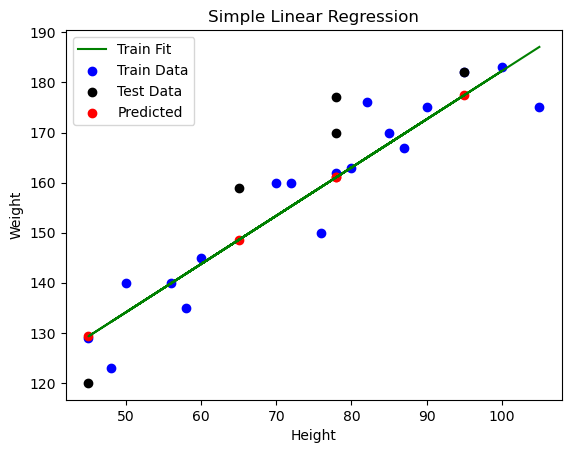

In [31]:
plt.plot(X_train, model.predict(X_train_scalar), color='green', label='Train Fit')
plt.scatter(X_train, y_train, color='blue', label='Train Data')
plt.scatter(X_test, y_test, color='black', label='Test Data')
plt.scatter(X_test, y_pred, color='red', label='Predicted')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()

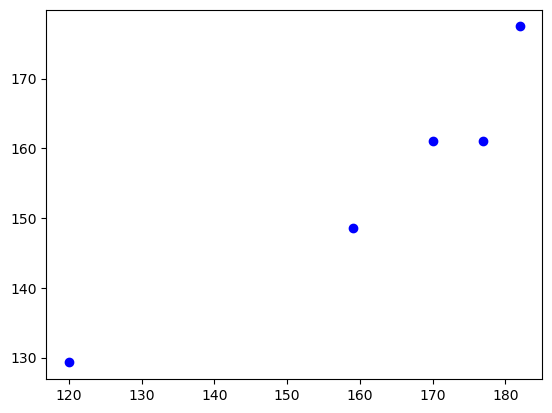

In [32]:
plt.scatter(y_test, y_pred, color='blue', label='error')

In [36]:
# NEw data point
new_weight = [[80]]
new_weight_scaled = scalar.transform(new_weight)
new_predicted_height = model.predict(new_weight_scaled)
print("New Scaled Weight 80:", new_weight_scaled[0])
print("Predicted Height for Weight 80:", new_predicted_height[0])

New Scaled Weight 80: [0.32350772]
Predicted Height for Weight 80: 163.01076265919562


c:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


C:\Users\Likhitha A V\AppData\Local\Temp\ipykernel_30628\1034678181.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals, kde=True)


<Axes: xlabel='Height', ylabel='Density'>

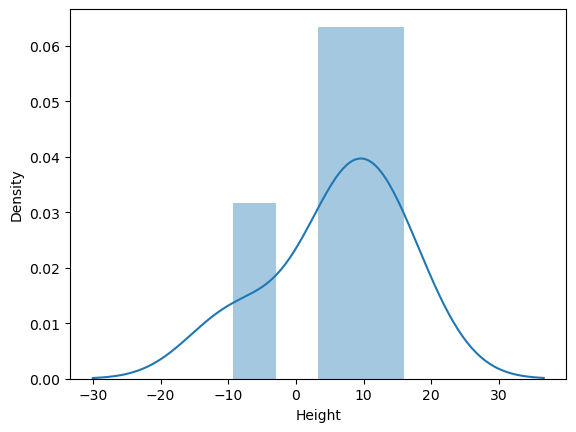

In [35]:
# Residuals
residuals = y_test - y_pred
import seaborn as sns
sns.distplot(residuals, kde=True)


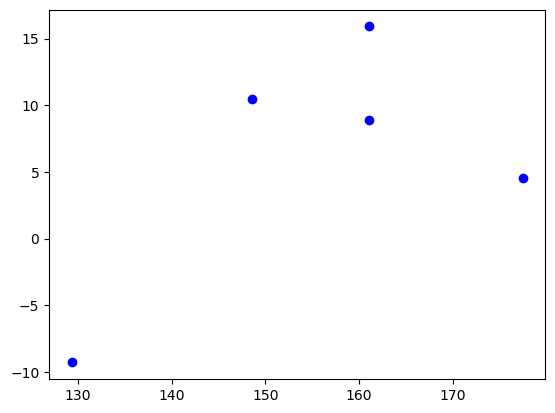

In [37]:
plt.scatter(y_pred, residuals, color='blue')